## Importing the Functions from various files

In [1]:
from services.doctor_service import get_specialities_list, get_doctor_info, generate_time_slots
from services.booking_service import confirm_booking
from agents.booking_agent import (
    BookingState,
    create_initial_state,
    build_booking_graph,
    process_message
)

## Build & Display the Graph

This notebook uses the existing functions from `agents.booking_agent` module to run an interactive clinic booking chatbot.


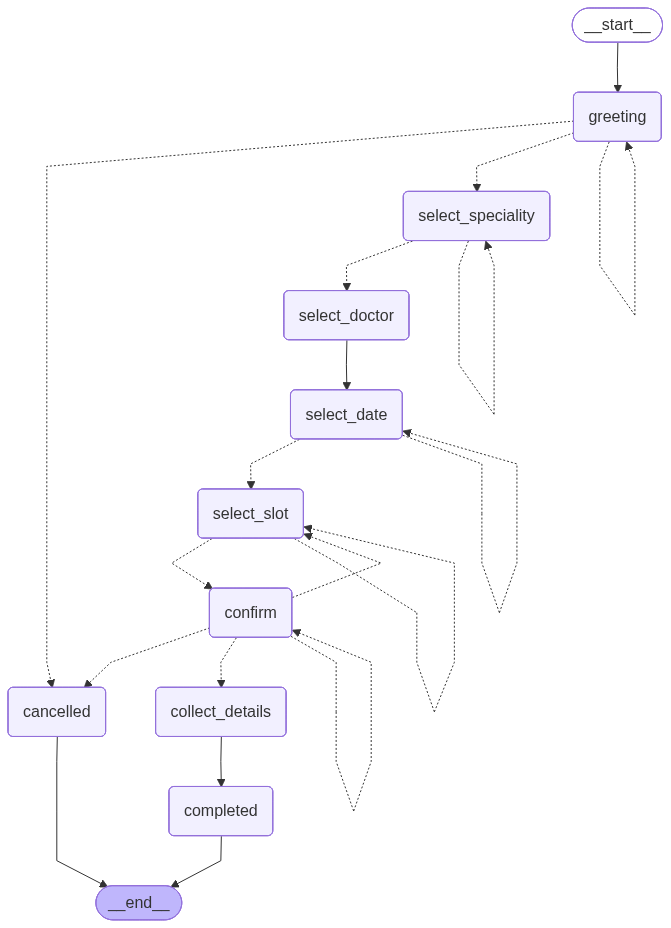

In [5]:
# Initialize the booking graph
booking_graph = build_booking_graph()

## Visualize the booking graph structure
from IPython.display import Image, display

png_bytes = booking_graph.get_graph().draw_mermaid_png()
display(Image(png_bytes))


## Running the Chatbot Session

In [4]:
from langgraph.types import Command

def run_booking_session(graph, thread_id="notebook_session", reset=False):
    config = {"configurable": {"thread_id": thread_id}}

    # 1. Start or Reset logic
    current_state = graph.get_state(config)
    if reset or not current_state.values:
        print(f"--- {'🔄 Resetting' if reset else '🆕 Initializing'} Session ---")
        # Using invoke() here kicks off the 'greeting' node immediately
        graph.invoke(create_initial_state(), config=config)

    print("---⚕⚕ Starting CarePlus Booking Session ---")
    
    last_displayed_message_idx = -1  # Track which messages have been displayed

    while True:
        state = graph.get_state(config)
        
        # Display any new assistant messages that haven't been shown yet
        # (This handles guardrail/off-topic responses)
        if state.values and state.values.get('messages'):
            messages = state.values['messages']
            for idx in range(last_displayed_message_idx + 1, len(messages)):
                msg = messages[idx]
                if msg.get("role") == "assistant":
                    print(f"\n[AI]: {msg['content']}")
            last_displayed_message_idx = len(messages) - 1

        # 2. Check for Interrupts
        if state.tasks and state.tasks[0].interrupts:
            interrupt_info = state.tasks[0].interrupts[0].value

            # --- FIX: Safely handle both String and Dict interrupts ---
            if isinstance(interrupt_info, dict):
                ai_message = interrupt_info.get('content', 'No message content')
                options = interrupt_info.get('available_options', [])
            else:
                ai_message = interrupt_info
                options = []

            print(f"\n[AI]: {ai_message}")
            if options:
                print(f"Options: {', '.join(options)}")
            # -------------------------------------------------------

            user_input = input("\n[YOU]: ")
            print(f"[YOU]: {user_input}")

            # Resume the graph with the user's input
            graph.invoke(Command(resume=user_input), config=config)

        # 3. Check if the graph has finished
        elif not state.next:
            # Before ending, check if there's a final assistant message to print
            if state.values and state.values.get('messages') and state.values['messages'][-1]["role"] == "assistant":
                if last_displayed_message_idx < len(state.values['messages']) - 1:
                    print(f"\n[AI]: {state.values['messages'][-1]['content']}")
            print("\n--- ⚑⚑ Session Ended ---")
            break

        # 4. If nodes are pending but no interrupt, let them run (the gas pedal)
        else:
            graph.invoke(None, config=config)

# IMPORTANT: Set reset=True only when you want to wipe the history.
# Set it to False to actually continue the conversation!
run_booking_session(booking_graph, reset=True)

--- 🔄 Resetting Session ---
---⚕⚕ Starting CarePlus Booking Session ---

[AI]: 👋 Welcome to CarePlus! Would you like to book an appointment?
Options: Book Appointment
[YOU]: Yes
LLM response: yes
LLM response: select_speciality
Routing decision: select_speciality

[AI]: 👋 Welcome to CarePlus! Would you like to book an appointment?

[AI]: Please choose a speciality:
Options: General Physician, Dermatologist, Orthopedic, Pediatrician, ENT Specialist
[YOU]: Derma
LLM response: Dermatologist
State-based bypass: specialty 'Dermatologist' selected. Moving to select_doctor.

[AI]: Please choose a speciality:

[AI]: We have Dermatologist, Dr. Neha Verma. When would you like to visit? We have slots for Today (2026-03-16) and Tomorrow (2026-03-17).

[AI]: We have Dermatologist, Dr. Neha Verma. When would you like to visit? We have slots for Today (2026-03-16) and Tomorrow (2026-03-17).
Options: Today, Tomorrow
[YOU]: Today
LLM response: 2026-03-16

[AI]: Pick a slot: 11:00 AM, 12:00 PM, 1:00 PM,